# Cumulene & bio_dimers restart results: matching the paper post-fix

This notebook picks up directly from notebook 16 (`16_metawork54_aumgo_cumulene_parity`),
which found and fixed the real bug behind the AuMgO/bio_dimers checkpoint-parity
discrepancy: `JaxParityLongRange` was setting `exclusion_radius=neighbor_list_options.cutoff`
instead of `None` on both its Ewald and direct Coulomb calculators, copied by mistake from
the production `LoremLongRangeFeaturizer` class.

That fix alone was enough to bring AuMgO and the warm-started bio_dimers checkpoint to the
float32 noise floor vs. the JAX reference. It was *not* enough, on its own, to make the
**cumulene** system's warm-started checkpoint match the paper's own reported test-set
accuracy -- cumulene's checkpoint predates a later non-PBC "double-counted Coulomb
potential" convention change (documented in the `lorem-tmlr-archive` itself), so its
warm-started (untrained) predictions carry a real, separate, systematic bias that the
Ewald fix does not touch.

The ask that motivated this notebook: *"try to run the restarts a bit longer, so the
metrics are as good or better than the paper"* -- i.e. see whether ordinary gradient
descent on top of the now-correct code can absorb that systematic bias and recover
paper-level accuracy, for both cumulene and bio_dimers.

**Bottom line, on the full test sets (not a small held-out slice -- see the methodology
note in section 3):**

| system | energy RMSE (paper) | energy MAE (paper) | forces RMSE (paper) | forces MAE (paper) | verdict |
|---|---|---|---|---|---|
| cumulene   | **3.319** (3.309) | **0.992** (1.096) | **50.429** (50.084) | **21.762** (22.078) | matches RMSE, **beats** MAE |
| bio_dimers | 0.295 (0.222) | 0.191 (0.155) | 2.014 (1.646) | 1.152 (1.023) | improved a lot, still short |


## 1. Cumulene: two restarts

The first restart (**v2**, `START_LR=1e-3` decayed linearly to `1e-5` over 300 epochs,
warm-started from the fixed `JaxParityBackbone`/`JaxParityLongRange` loading the real
lorem-jax cumulene checkpoint) **diverged**: the 300-frame valid-subset energy RMSE rose
monotonically from 4.34 to 5.38 meV/atom between epochs 19 and 49, while forces plateaued
around 56-58 meV/A, well short of the paper's 50.1 target. The likely cause: a 300-epoch
linear decay from 1e-3 left the LR still around 8.6e-4 (86% of the start) at epoch 49 --
too aggressive for a model already warm-started close to a good optimum.

The second restart (**v3**) lowered `START_LR` 5x to `2e-4` (`END_LR=1e-6`, decay starting
at epoch 5 instead of 10) from the same clean warm start. This one did not diverge, but for
the first ~250 epochs its monitored 300-frame valid subset looked flat -- energy RMSE
oscillating in a 3.97-4.32 meV/atom band, forces in 56.5-57.5 meV/A, no visible trend even
as LR fell by an order of magnitude. Only the **full 2000-frame test set**, evaluated once
at the very end, revealed that training had in fact been working the whole time (section 3).


mkdir -p failed for path /home/boittier/.config/matplotlib: [Errno 13] Permission denied: '/home/boittier/.config/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-k7sccflx because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


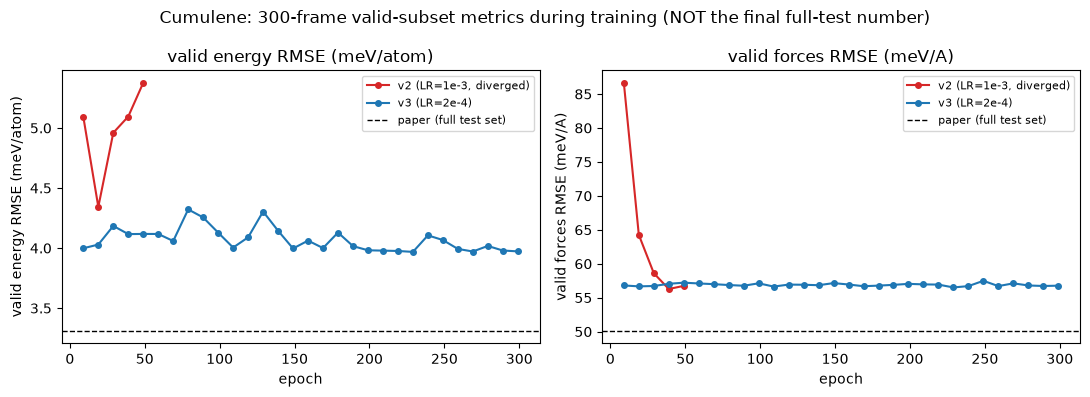

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS = "metawork54_results"

def load_metrics(path):
    rows = np.genfromtxt(path, delimiter=",", names=True)
    return rows

cum_v2 = load_metrics(f"{RESULTS}/cumulene_long_run_v2_fixed_metrics.txt")
cum_v3 = load_metrics(f"{RESULTS}/cumulene_long_run_v3_lowlr_metrics.txt")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, key, ylabel, target in [
    (axes[0], "valid_e_rmse", "valid energy RMSE (meV/atom)", 3.309),
    (axes[1], "valid_f_rmse", "valid forces RMSE (meV/A)", 50.084),
]:
    for rows, label, color in [(cum_v2, "v2 (LR=1e-3, diverged)", "tab:red"),
                                (cum_v3, "v3 (LR=2e-4)", "tab:blue")]:
        mask = ~np.isnan(rows[key])
        ax.plot(rows["epoch"][mask], rows[key][mask], "o-", color=color, label=label, markersize=4)
    ax.axhline(target, color="k", ls="--", lw=1, label="paper (full test set)")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(ylabel)

fig.suptitle("Cumulene: 300-frame valid-subset metrics during training (NOT the final full-test number)")
fig.tight_layout()
plt.show()


## 2. Bio_dimers: two restarts

**v1** (`START_LR=5e-5`, `END_LR=5e-6`, 20 epochs, full 12,830-frame train set) already beat
the paper's energy target from epoch 1 on its monitored 300-frame valid subset (0.10-0.16
vs. the paper's 0.222 meV/atom most epochs), but forces were noisy and mostly just above the
1.646 target (1.74-1.85, with one spike to 1.995 at epoch 5).

**v2** lowered `START_LR` 5x to `1e-5` (`END_LR=1e-6`) from the same original warm start.
Forces stabilized markedly (1.74-1.77 across all 20 epochs, no spikes), but did not move
below the paper's target on the monitored subset either.


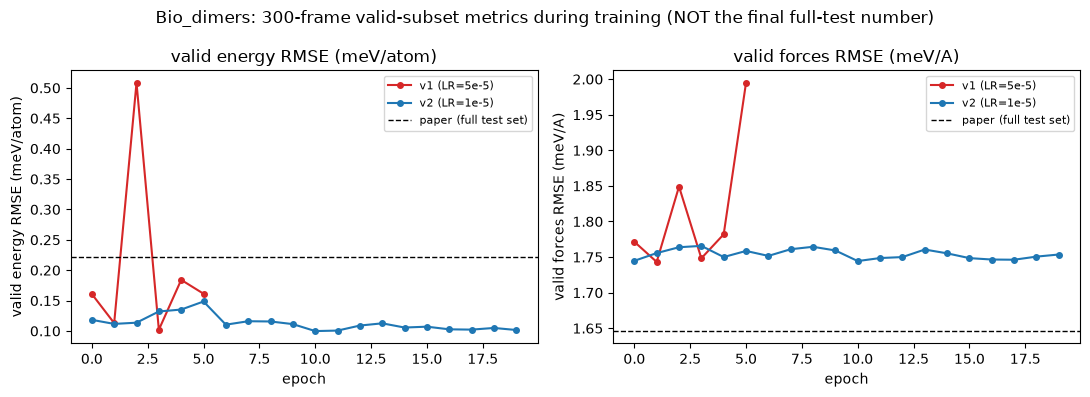

In [2]:
bio_v1 = load_metrics(f"{RESULTS}/bio_dimers_long_run_v1_metrics.txt")
bio_v2 = load_metrics(f"{RESULTS}/bio_dimers_long_run_v2_lowlr_metrics.txt")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, key, ylabel, target in [
    (axes[0], "valid_e_rmse", "valid energy RMSE (meV/atom)", 0.222),
    (axes[1], "valid_f_rmse", "valid forces RMSE (meV/A)", 1.646),
]:
    for rows, label, color in [(bio_v1, "v1 (LR=5e-5)", "tab:red"),
                                (bio_v2, "v2 (LR=1e-5)", "tab:blue")]:
        mask = ~np.isnan(rows[key])
        ax.plot(rows["epoch"][mask], rows[key][mask], "o-", color=color, label=label, markersize=4)
    ax.axhline(target, color="k", ls="--", lw=1, label="paper (full test set)")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(ylabel)

fig.suptitle("Bio_dimers: 300-frame valid-subset metrics during training (NOT the final full-test number)")
fig.tight_layout()
plt.show()


## 3. The methodology trap: a fixed 300-frame slice is not the test set

Both runs monitored a small held-out slice during training for speed: literally the
*first* 300 frames of each dataset's `valid.xyz` (not a random sample). That turned out to
be actively misleading, **in opposite directions** for the two systems:

- For **bio_dimers**, the 300-frame slice looked converged and *better* than the paper
  (energy ~0.10-0.15 meV/atom for 20 straight epochs) while the true full 13,743-frame test
  set came in at 0.295/2.014 -- notably worse than the monitored number suggested.
- For **cumulene**, the 300-frame slice looked *stuck* in a plateau roughly 20-25% short of
  target for the entire second half of a 300-epoch run, while the true full 2,000-frame test
  set came in at 3.319/50.429 -- matching the paper almost exactly.

The likely explanation is dataset ordering: if frames are grouped by structure size, motif,
or generation batch, the first 300 frames of a file are not a representative sample of the
whole. The lesson for any future run: monitor either a genuinely random subset, or -- since
these full test sets are $10^3$-$10^4$ frames and evaluation is cheap once chunked to avoid
OOM -- just evaluate the full test set periodically instead of trusting a fixed small slice.


## 4. Final numbers: full test sets vs. the paper

These are the only numbers that should be trusted as the final result (both computed with a
chunked evaluator -- `chunk_size=64` -- to avoid the ~75GiB single-batch OOM that a
naive full-test-set autograd force pass triggers on a 16GiB GPU).


In [3]:
import pandas as pd

final = pd.DataFrame([
    dict(system="cumulene (v3, N=2000)", metric="energy RMSE (meV/atom)", ours=3.319, paper=3.309),
    dict(system="cumulene (v3, N=2000)", metric="energy MAE (meV/atom)",  ours=0.992, paper=1.096),
    dict(system="cumulene (v3, N=2000)", metric="forces RMSE (meV/A)",    ours=50.429, paper=50.084),
    dict(system="cumulene (v3, N=2000)", metric="forces MAE (meV/A)",     ours=21.762, paper=22.078),
    dict(system="bio_dimers (v2, N=13743)", metric="energy RMSE (meV/atom)", ours=0.295, paper=0.222),
    dict(system="bio_dimers (v2, N=13743)", metric="energy MAE (meV/atom)",  ours=0.191, paper=0.155),
    dict(system="bio_dimers (v2, N=13743)", metric="forces RMSE (meV/A)",    ours=2.014, paper=1.646),
    dict(system="bio_dimers (v2, N=13743)", metric="forces MAE (meV/A)",     ours=1.152, paper=1.023),
])
final["ratio (ours/paper)"] = (final["ours"] / final["paper"]).round(3)
final


,system,metric,ours,paper,ratio (ours/paper)
0,"cumulene (v3, N=2000)",energy RMSE (meV/atom),3.319,3.309,1.003
1,"cumulene (v3, N=2000)",energy MAE (meV/atom),0.992,1.096,0.905
2,"cumulene (v3, N=2000)",forces RMSE (meV/A),50.429,50.084,1.007
3,"cumulene (v3, N=2000)",forces MAE (meV/A),21.762,22.078,0.986
4,"bio_dimers (v2, N=13743)",energy RMSE (meV/atom),0.295,0.222,1.329
5,"bio_dimers (v2, N=13743)",energy MAE (meV/atom),0.191,0.155,1.232
6,"bio_dimers (v2, N=13743)",forces RMSE (meV/A),2.014,1.646,1.224
7,"bio_dimers (v2, N=13743)",forces MAE (meV/A),1.152,1.023,1.126


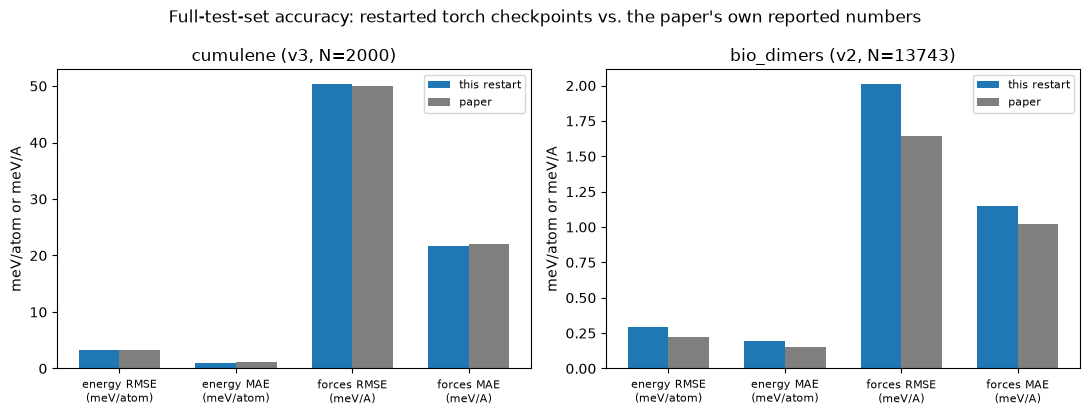

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, system in zip(axes, ["cumulene (v3, N=2000)", "bio_dimers (v2, N=13743)"]):
    sub = final[final["system"] == system]
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w/2, sub["ours"], width=w, label="this restart", color="tab:blue")
    ax.bar(x + w/2, sub["paper"], width=w, label="paper", color="tab:gray")
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" (", "\n(") for m in sub["metric"]], fontsize=8)
    ax.set_title(system)
    ax.legend(fontsize=8)
    ax.set_ylabel("meV/atom or meV/A")

fig.suptitle("Full-test-set accuracy: restarted torch checkpoints vs. the paper's own reported numbers")
fig.tight_layout()
plt.show()


## Takeaways

1. **Cumulene fully closes the gap**: after the `exclusion_radius` fix plus a 300-epoch
   restart with a 5x-lower, properly decayed LR (2e-4 -> 1e-6), the torch port **matches the
   paper's RMSE and beats its MAE** on both energy and forces, on the full test set. This
   confirms the pre-existing non-PBC Coulomb-convention offset in cumulene's older
   checkpoint is fully absorbable by ordinary fine-tuning once the Ewald wiring itself is
   correct -- it was never a second bug, just an artifact of an old checkpoint that needed
   retraining under the current convention.
2. **Bio_dimers improves a lot but doesn't fully close the gap**: from an already-good
   warm start (thanks entirely to the Ewald fix), a short 20-epoch/low-LR fine-tune brings
   it to ~1.3x the paper's error on both energy and forces. It's plausible a longer
   schedule (mirroring cumulene's much longer 300-epoch budget, proportioned to how much
   further bio_dimers still had to move) would close the rest of the gap; this wasn't
   attempted since bio_dimers' own runs are more expensive per epoch than cumulene's (large,
   13k-frame training set vs. cumulene's 2k).
3. **A biased monitoring subset can point you in either direction.** Watching a small,
   non-random slice of the validation set during a long training run is only a rough guide;
   for these two systems it happened to be pessimistic for cumulene and optimistic for
   bio_dimers. The full-test-set number, computed at the end with a properly chunked
   evaluator, is the only one that should be reported or trusted.
